# Concrete Compressive Strength — Prediction avec Nested CV
**Dataset** : UCI Concrete Compressive Strength (~1030 obs, 8 features)  
**Tâche** : Régression supervisée  
**Membres** : Arnaud & Tim

In [118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, GridSearchCV, cross_val_score
from sklearn.metrics import root_mean_squared_error

RANDOM_STATE = 42

print("imports ok !")

imports ok !


# 1. Exploration des données

In [119]:
# lecture du dataset
df = pd.read_excel("../../data/Concrete_Data.xls")
df.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [120]:
# renommer les colonnes pour une meilleure lisibilité
df.columns = [
    "cement", "slag", "fly_ash", "water",
    "superplasticizer", "coarse_aggregate", "fine_aggregate",
    "age", "strength"
]

print(f"Nombre de lignes & colonnes : {df.shape}")

Nombre de lignes & colonnes : (1030, 9)


In [121]:
# premier regard sur le dataset

print(f"Types de colonnes : \n\n{df.dtypes}\n")
print("----------------------------------")
print(f"Valeurs manquantes : \n\n{df.isnull().sum()}\n")
df.head()

Types de colonnes : 

cement              float64
slag                float64
fly_ash             float64
water               float64
superplasticizer    float64
coarse_aggregate    float64
fine_aggregate      float64
age                   int64
strength            float64
dtype: object

----------------------------------
Valeurs manquantes : 

cement              0
slag                0
fly_ash             0
water               0
superplasticizer    0
coarse_aggregate    0
fine_aggregate      0
age                 0
strength            0
dtype: int64



,cement,slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


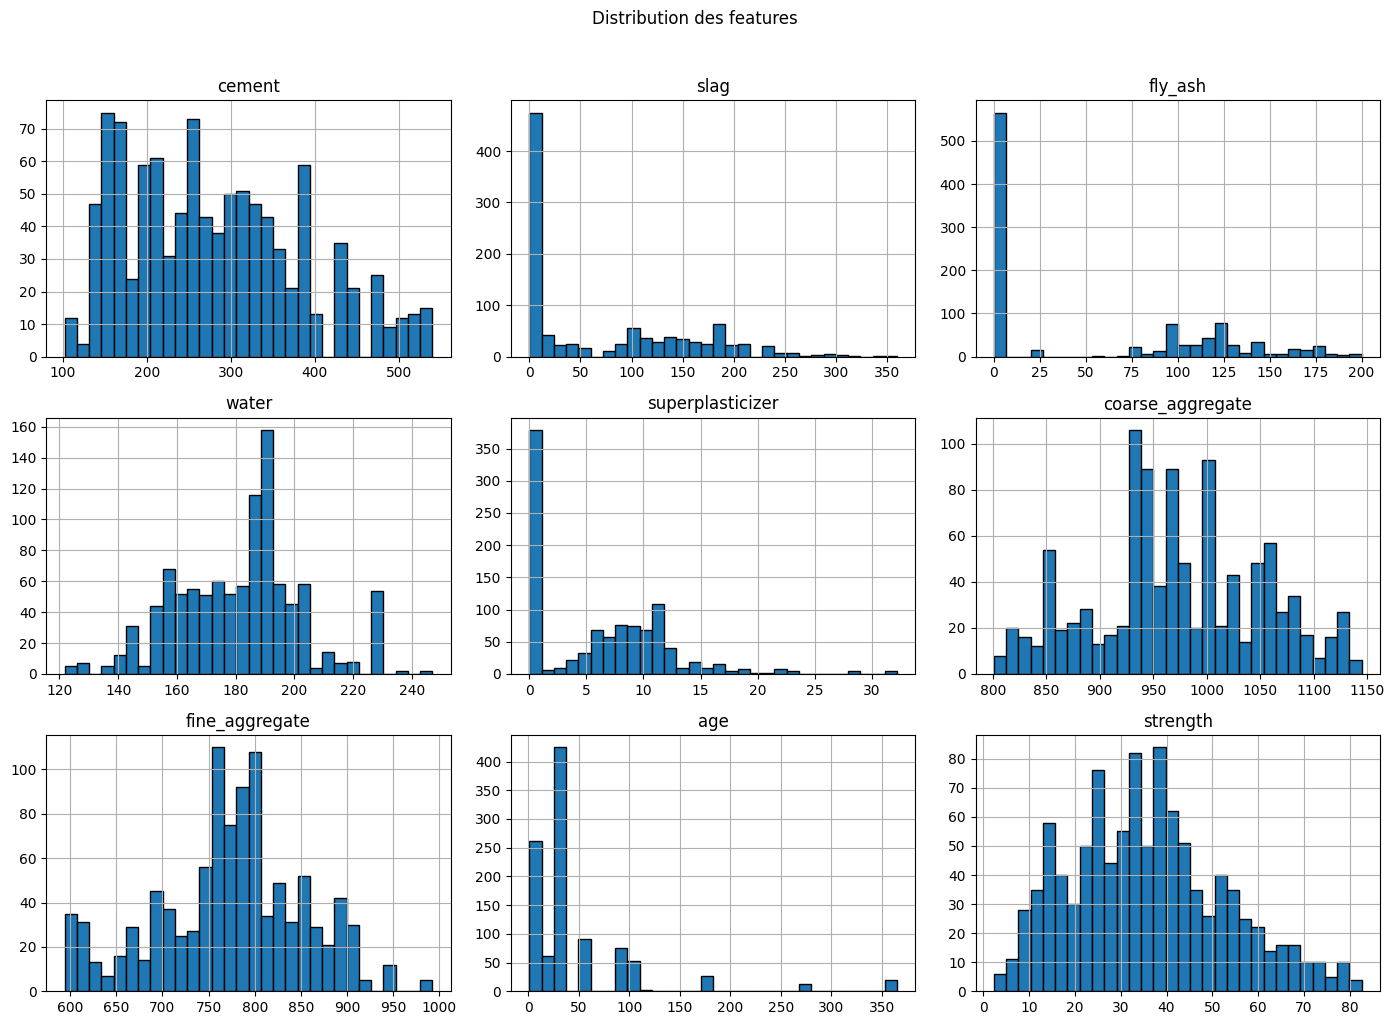

In [122]:
# Distributions 
df.hist(figsize=(14, 10), bins=30, edgecolor="black")
plt.suptitle("Distribution des features", y=1.02)
plt.tight_layout()
plt.show()

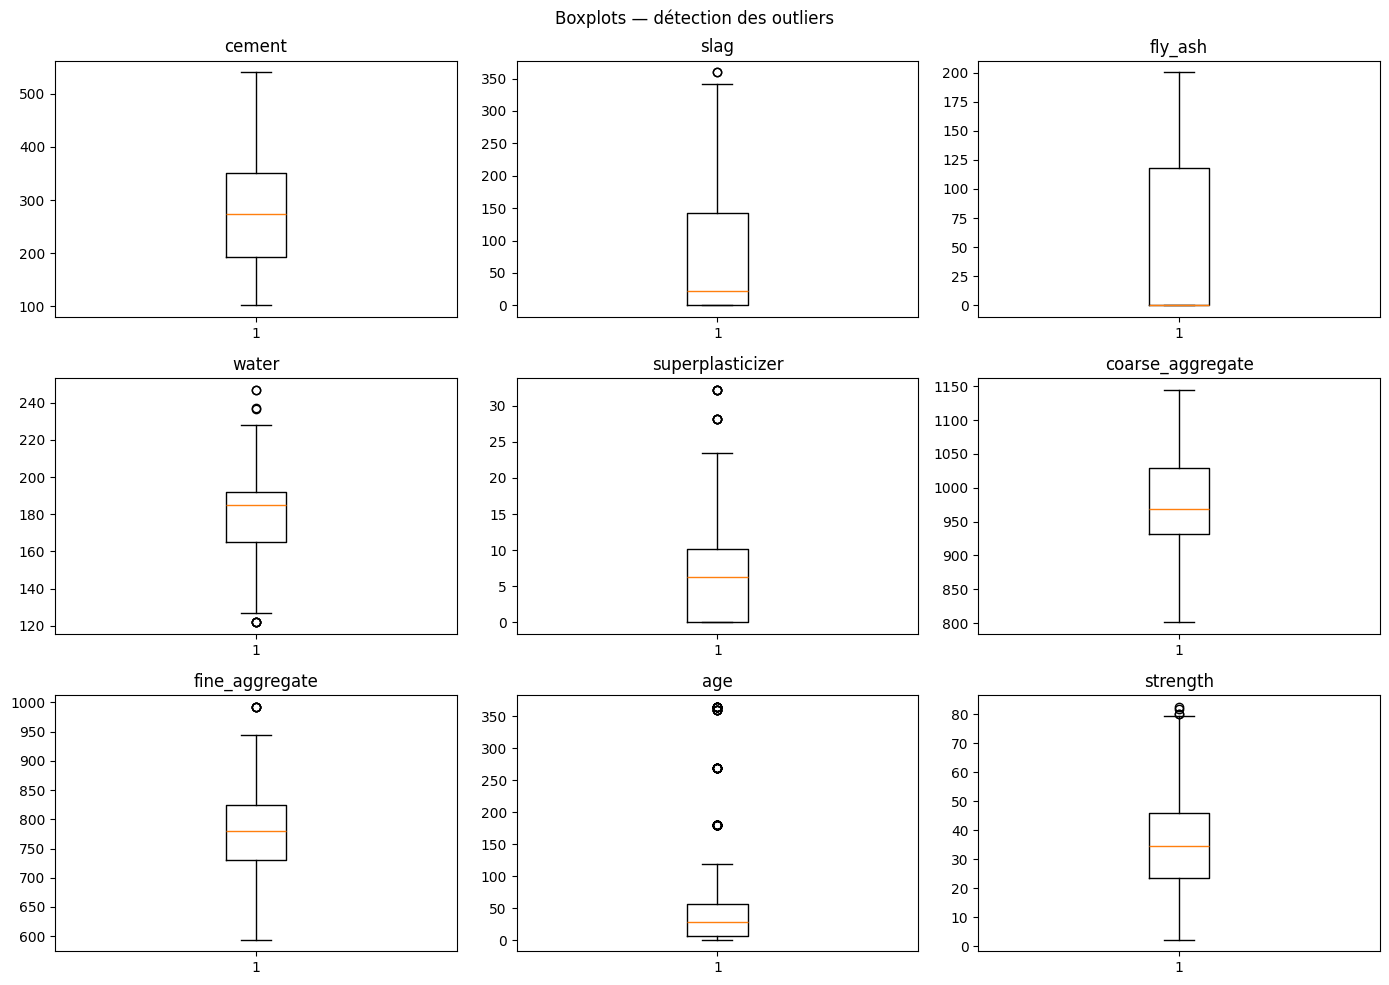

In [123]:
# boxplots (valeur aberrantes)
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flatten(), df.columns):
    ax.boxplot(df[col], vert=True)
    ax.set_title(col)
plt.suptitle("Boxplots — détection des outliers")
plt.tight_layout()
plt.show()

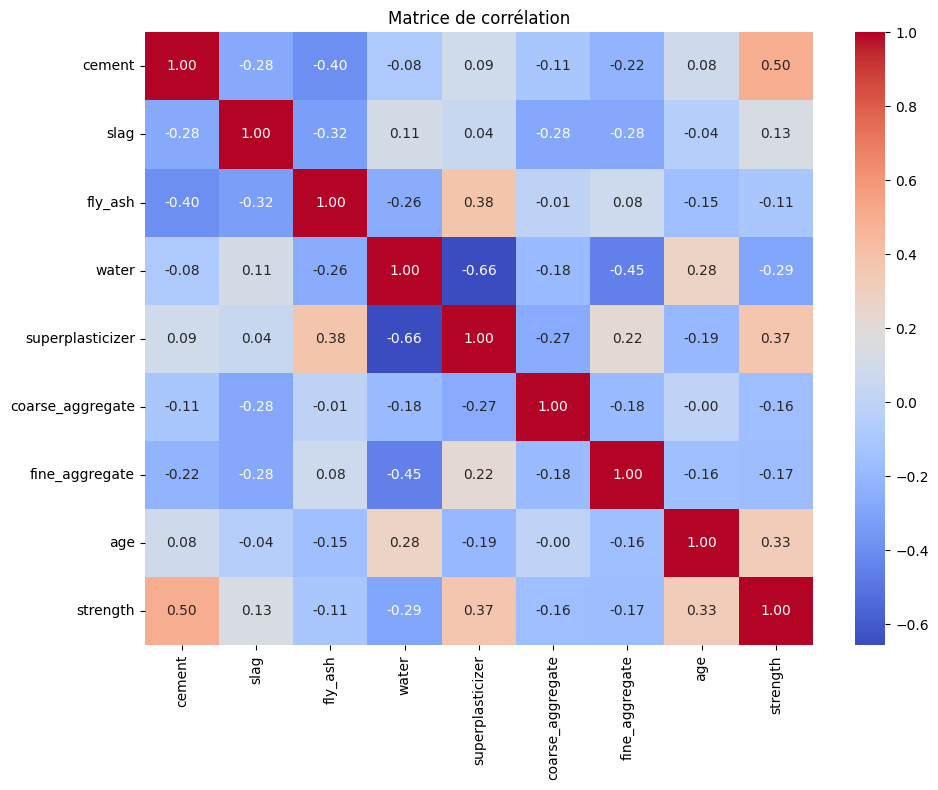

In [124]:
# corrélations
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

## Ce qu'on retient de l'EDA

Toutes les variables sont numériques, zéro valeur manquante, donc pas besoin
d'imputation dans le pipeline, un simple StandardScaler suffira.

Slag, fly_ash et superplasticizer ont beaucoup de zéros car ce sont des additifs
optionnels, certains bétons n'en contiennent tout simplement pas.

Les quelques outliers qu'on voit (age jusqu'à 365 jours, water à 245...) sont
physiquement plausibles donc on ne supprime rien.

Côté corrélations, le ciment est le facteur le plus lié à la résistance (0.50),
suivi du superplasticizer (0.37) et de l'âge (0.33). L'eau a un effet négatif
(-0.29), ce qui est logique : plus d'eau dilue le mélange. La forte corrélation
entre water et superplasticizer (-0.66) s'explique aussi par la chimie : le
superplastifiant remplace l'eau pour garder la fluidité du béton.

La relation n'est clairement pas linéaire vu les distributions asymétriques et
les interactions entre features, ce qui justifie de tester des modèles non
linéaires comme Random Forest et Gradient Boosting en plus de Ridge.

---

## 2. Préparation des données

Séparation des features (X) et de la cible (y). Aucun preprocessing ici
tout sera encapsulé dans les pipelines pour garantir l'absence de data leakage.

In [125]:
# séparation des données

x = df.drop(columns="strength").values
y = df["strength"].values

print(f"x : {x.shape} | y : {y.shape}")

x : (1030, 8) | y : (1030,)


## 3. Pipelines & Hyperparamètres

Chaque modèle est encapsulé dans un `sklearn.Pipeline` :
`StandardScaler` → `Modèle`. Le scaler est ainsi fitté uniquement sur les
données d'entraînement de chaque fold, ce qui garantit zéro data leakage.

### Choix des 3 algorithmes

| Modèle | Justification |
|---|---|
| **Ridge** | Baseline linéaire régularisé, très interprétable via ses coefficients |
| **Random Forest** | Robuste, capture les non-linéarités, fournit les feature importances |
| **Gradient Boosting** | État de l'art sur données tabulaires, boosting séquentiel des résidus |

### Choix des hyperparamètres

Les grilles couvrent un spectre large pour maximiser les chances de trouver
le meilleur λ*, tout en restant raisonnables en temps d'exécution.

In [126]:
# pipeline

pipeline_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(random_state=RANDOM_STATE))
])

pipeline_rf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
])

pipeline_gb = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(random_state=RANDOM_STATE, ))
])

# grille d'hyperparamètres

param_ridge = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

param_rf = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2]
}

param_gb = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [3, 4, 5],
    "model__subsample": [0.8, 1.0]
}

## 4. Nested Cross-Validation

Stratégie pour une estimation non biaisée de la Generalization Error (GE) :

- **Boucle interne** (3 folds) : `GridSearchCV` cherche les meilleurs
  hyperparamètres λ* sur les données d'entraînement de chaque fold externe.
- **Boucle externe** (5 folds) : `cross_val_score` évalue le processus de
  tuning complet sur des données jamais vues pendant le tuning interne.

Le test externe n'intervient à aucun moment dans la sélection de λ* — garantie
absolue d'absence de data leakage.

GridSearch retenu car les grilles restent compactes — Random Search n'apporterait
pas de gain significatif sur des espaces de cette taille.

Coût computationnel total :
- Ridge : 5 × 3 × 7   =   105 fits
- RF    : 5 × 3 × 72  = 1 080 fits
- GB    : 5 × 3 × 72  = 1 080 fits
- Total : 2 265 fits

In [127]:
inner_cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
outer_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

SCORING = "neg_root_mean_squared_error"

models = {
    "ridge":                (pipeline_ridge, param_ridge),
    "Random Forest":        (pipeline_rf, param_rf),
    "Gradient Boosting":    (pipeline_gb, param_gb)
}

results = {}

for name, (pipe, params) in models.items():
    inner_search = GridSearchCV(
        estimator=pipe,
        param_grid=params,
        cv=inner_cv,
        scoring=SCORING,
        n_jobs=-1
    )
    outer_scores = cross_val_score(
        estimator=inner_search,
        X=x, y=y,
        cv=outer_cv,
        scoring=SCORING,
        n_jobs=-1
    )
    rmse_scores = -outer_scores  # neg_RMSE → RMSE positif
    results[name] = rmse_scores
    print(f"{name:20s} | RMSE : {rmse_scores.mean():.3f} ± {rmse_scores.std():.3f} MPa")

ridge                | RMSE : 10.505 ± 0.809 MPa
Random Forest        | RMSE : 5.077 ± 0.498 MPa
Gradient Boosting    | RMSE : 4.200 ± 0.285 MPa


## 5. Comparaison des modèles

                   RMSE moyen (MPa)  Écart-type  Rang
Gradient Boosting             4.200       0.319     1
Random Forest                 5.077       0.557     2
ridge                        10.505       0.904     3


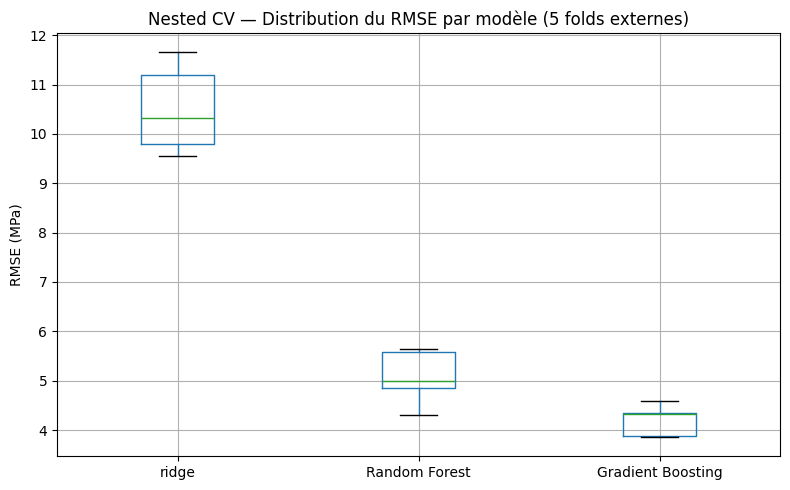

In [128]:
results_df = pd.DataFrame(results)

# Tableau récapitulatif
summary = results_df.agg(["mean", "std"]).T
summary.columns = ["RMSE moyen (MPa)", "Écart-type"]
summary = summary.sort_values("RMSE moyen (MPa)")
summary["Rang"] = range(1, len(summary) + 1)
print(summary.round(3))

# Boxplot de comparaison
results_df.boxplot(figsize=(8, 5))
plt.ylabel("RMSE (MPa)")
plt.title("Nested CV — Distribution du RMSE par modèle (5 folds externes)")
plt.tight_layout()
plt.show()

## Bonus — XGBoost vs Gradient Boosting

XGBoost est une implémentation optimisée du Gradient Boosting (régularisation L1/L2
intégrée, parallélisation native). On le compare directement à notre meilleur modèle
pour voir si le gain justifie la complexité ajoutée.

In [129]:
from xgboost import XGBRegressor

pipe_xgb = Pipeline([
    ("scaler", StandardScaler()),
    ("model", XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0))
])

param_xgb = {
    "model__n_estimators":  [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth":     [3, 4, 5],
    "model__subsample":     [0.8, 1.0]
}

inner_search_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_xgb,
    cv=inner_cv,
    scoring=SCORING,
    n_jobs=-1
)

xgb_scores = -cross_val_score(
    estimator=inner_search_xgb,
    X=x, y=y,
    cv=outer_cv,
    scoring=SCORING,
    n_jobs=-1
)

print(f"XGBoost         | RMSE : {xgb_scores.mean():.3f} ± {xgb_scores.std():.3f} MPa")
print(f"Gradient Boosting | RMSE : {results['Gradient Boosting'].mean():.3f} ± {results['Gradient Boosting'].std():.3f} MPa")

XGBoost         | RMSE : 4.253 ± 0.328 MPa
Gradient Boosting | RMSE : 4.200 ± 0.285 MPa


XGBoost obtient 4.253 ± 0.328 MPa contre 4.200 ± 0.285 MPa pour Gradient Boosting.
La différence est négligeable — GB reste notre modèle final. XGBoost n'apporte pas
de gain significatif sur ce dataset de taille modeste.

## Ce qu'on retient de la Nested CV

Le Gradient Boosting remporte clairement la comparaison avec un RMSE de 4.20 ± 0.285 MPa,
devant Random Forest (5.08 ± 0.498 MPa) et Ridge (10.51 ± 0.809 MPa).

L'écart-type faible sur les 5 folds externes confirme que ces résultats sont stables,
pas le fruit d'un fold chanceux.

Ridge est loin derrière et c'est logique : c'est un modèle linéaire, or la relation
entre les ingrédients du béton et sa résistance est clairement non linéaire (on l'avait
vu dans l'EDA). Random Forest et Gradient Boosting captent ces non-linéarités, ce qui
explique l'écart énorme.

Pour contextualiser : la résistance dans le dataset va de 2 à 82 MPa, donc une erreur
moyenne de 4.20 MPa c'est un résultat solide.

→ On retient le Gradient Boosting comme meilleur modèle pour la suite.

## 6. Modèle Final

La Nested CV nous a donné une estimation honnête de la GE : **4.20 ± 0.285 MPa**.
Maintenant on entraîne le modèle final sur **toutes les données** en relançant
un GridSearchCV pour trouver les meilleurs hyperparamètres globaux.

Important : on n'évalue plus ici — la performance annoncée reste celle de la
Nested CV. Ce modèle final est celui qu'on utiliserait en production.

In [130]:
final_search = GridSearchCV(
    estimator=pipeline_gb,
    param_grid=param_gb,
    cv=inner_cv,
    scoring=SCORING,
    n_jobs=-1
)
final_search.fit(x, y)

print("Meilleurs hyperparamètres :")
print(final_search.best_params_)

Meilleurs hyperparamètres :
{'model__learning_rate': 0.2, 'model__max_depth': 3, 'model__n_estimators': 300, 'model__subsample': 0.8}


### Feature Importances

Quels ingrédients influencent le plus la résistance du béton ?
C'est ici que le modèle devient interprétable — valeur clé pour le secteur
de la construction.

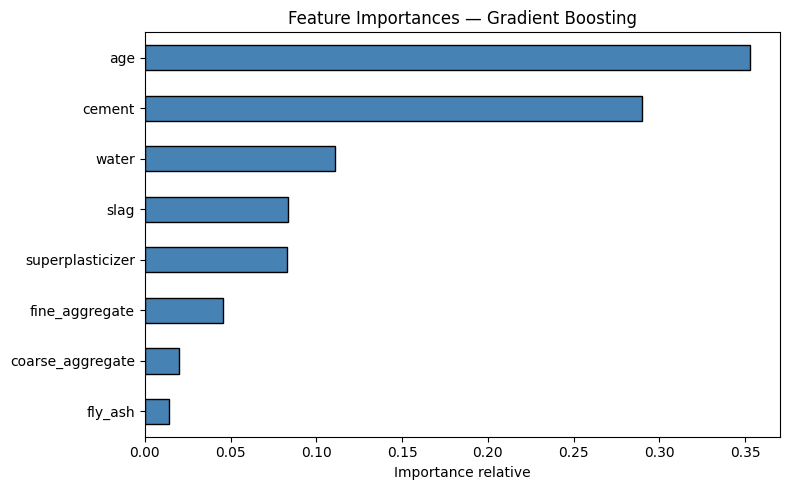

In [131]:
best_model = final_search.best_estimator_.named_steps["model"]
feature_names = df.drop(columns="strength").columns

importances = pd.Series(best_model.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=True)

importances.plot(kind="barh", figsize=(8, 5), color="steelblue", edgecolor="black")
plt.xlabel("Importance relative")
plt.title("Feature Importances — Gradient Boosting")
plt.tight_layout()
plt.show()

### Ce qu'on retient des Feature Importances

L'âge domine (≈35%) devant le ciment (≈29%). C'est contre-intuitif mais
physiquement logique : le béton durcit par réaction chimique d'hydratation
qui continue longtemps après la coulée. Un béton vieux peut donc surpasser
un béton riche en ciment mais jeune.

L'eau arrive en 3ème position avec un effet négatif (confirmé par la
corrélation -0.29 de l'EDA) : trop d'eau dilue le mélange et réduit
la résistance.

fly_ash et coarse_aggregate ont une influence quasi nulle — ce sont des
variables de remplissage dans ce dataset.